In [1]:
import yaml
import numpy as np
from TraceSimulator import LongTraceSimulator
import matplotlib.pyplot as plt
from trace_IO import *


def read_yaml_to_dict(file_path):
    with open(file_path, 'r') as file:
        config_dict = yaml.safe_load(file)
    return config_dict

config = read_yaml_to_dict('/ceph/dwong/delight_conf/ETP_config_v2.yaml')
lts = LongTraceSimulator(config)



The history saving thread hit an unexpected error (DatabaseError('database disk image is malformed')).History will not be written to the database.


/home/dwong/software/TraceSimulator/TraceSimulator/LongTraceSimulator.py:203: RuntimeWarning: overflow encountered in exp
  self.template = np.concatenate([(np.exp((xs - self.trigger_time) / self.tau_rise))[xs <= self.trigger_time], (np.exp(-(xs - self.trigger_time) / self.tau_decay))[xs > self.trigger_time]])


In [9]:
trace, signal_mask= lts.generate(
            E=20000,
            x=0,
            y=0,
            z=-1700,
            no_noise=True,
            type_recoil='NR',
            quantize=True,
            phonon_only=True,
            return_signal_mask=True
        )

In [10]:
trace.shape

(1, 56, 300000)

In [11]:
signal_mask.shape

(1, 56)

In [12]:
signal_mask

array([[False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True]])

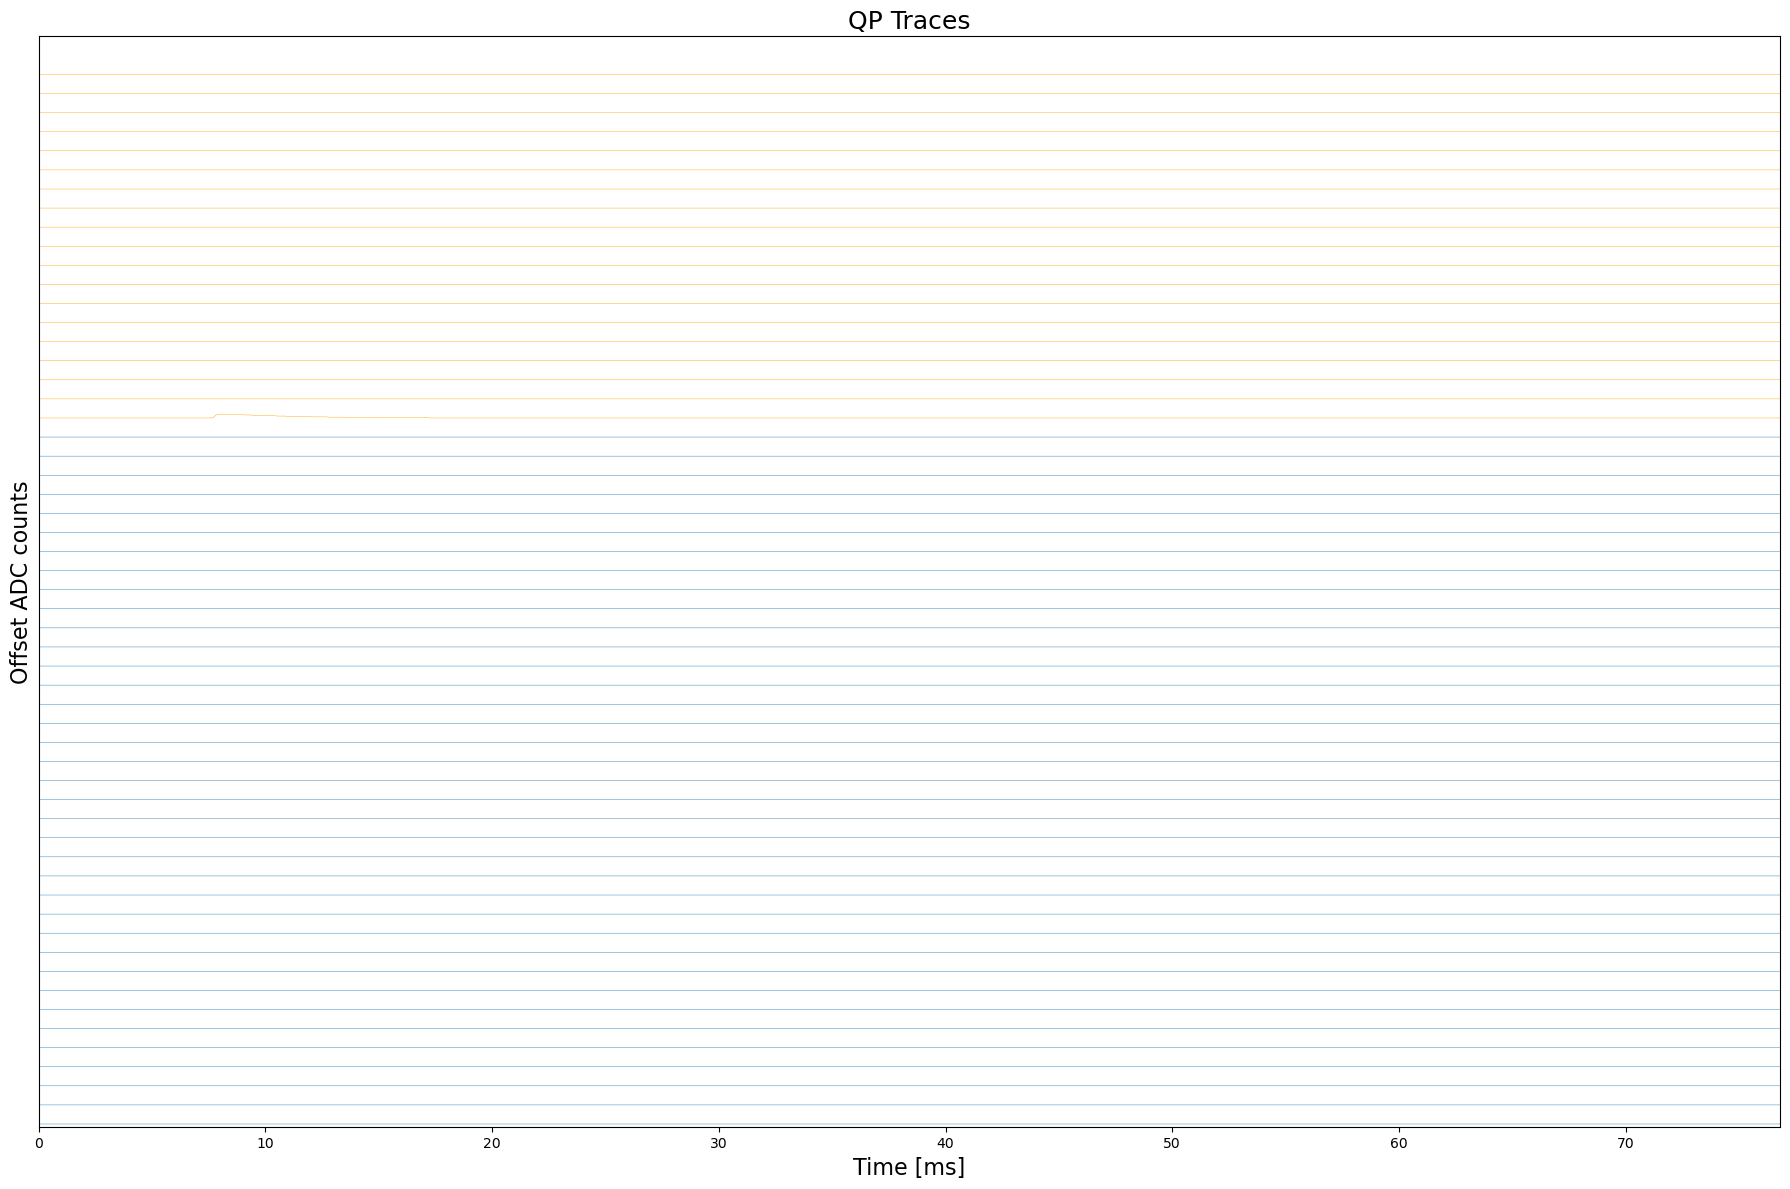

In [12]:
plot_traces(trace)

In [7]:
import numpy as np

# Example: trace is shape (n_traces, n_samples)
# trace = np.random.randn(54, 32768)

# Get maximum value along each trace (row)
max_values = np.max(trace, axis=1)

max_values


array([[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        1.37233304e-06, 1.37221594e-06, 1.37209885e-06]])

In [2]:
import os
import numpy as np
import zstandard as zstd
from concurrent.futures import ThreadPoolExecutor, as_completed
from pathlib import Path
from tqdm import tqdm

# -------------------------------------------------
# Assumes you have an lts object available, e.g.:
# from your_module import lts
# -------------------------------------------------

# -------------------
# Config
# -------------------
N_SETS = 100                    # traces per energy
TRACE_SAMPLES = 300_000         # must match long_trace_samples passed to lts.generate
DTYPE = np.float16
COMPRESSION_LEVEL = 15
#ENERGIES = list(range(5, 35, 5))  # [5,10,15,20,25,30]
ENERGIES = [0]
MAX_THREADS = 15
OUTDIR = Path(f"/ceph/dwong/trigger_samples/v2_300k")

# Signal detection params (should match your generate() implementation)
SIGNAL_THRESHOLD = 1.0  # pre-noise, pre-quant peak > threshold => signal


# -------------------
# I/O helpers: TRACES
# -------------------
def _shuffle_bytes(arr: np.ndarray) -> bytes:
    """Byte-shuffle for better compression (float16/float32)."""
    return arr.view(np.uint8).reshape(-1, arr.itemsize).T.tobytes()


def save_traces_to_zstd(traces, output_path: Path,
                        dtype=DTYPE, trace_shape=None, compression_level=COMPRESSION_LEVEL):
    """
    Save a list of arrays with identical shape=trace_shape and dtype to a .zst file.
    Layout: concatenated, byte-shuffled per trace.
    """
    if trace_shape is None:
        if not traces:
            raise ValueError("No traces to save and trace_shape not provided.")
        trace_shape = traces[0].shape

    all_data = bytearray()
    for trace in traces:
        if trace.shape != trace_shape:
            raise ValueError(f"Trace has wrong shape {trace.shape}, expected {trace_shape}")
        shuffled = _shuffle_bytes(np.asarray(trace, dtype=dtype))
        all_data.extend(shuffled)

    compressor = zstd.ZstdCompressor(level=compression_level)
    compressed_data = compressor.compress(bytes(all_data))

    output_path.parent.mkdir(parents=True, exist_ok=True)
    with open(output_path, "wb") as f:
        f.write(compressed_data)


def load_traces_from_zstd(input_path: Path, n_traces: int,
                          dtype=DTYPE, trace_shape=None) -> np.ndarray:
    """
    Load stacked ndarray of shape (n_traces, *trace_shape) from a .zst file written by save_traces_to_zstd.
    """
    if trace_shape is None:
        raise ValueError("trace_shape must be provided to load traces.")

    def _unshuffle_bytes(data: bytes, dtype=dtype, shape=trace_shape) -> np.ndarray:
        itemsize = np.dtype(dtype).itemsize
        num_elements = int(np.prod(shape))
        reshaped = np.frombuffer(data, dtype=np.uint8).reshape(itemsize, num_elements).T
        unshuffled = reshaped.reshape(-1)
        return unshuffled.view(dtype).reshape(shape)

    decompressor = zstd.ZstdDecompressor()
    with open(input_path, "rb") as f:
        decompressed = decompressor.decompress(f.read())

    trace_size_bytes = int(np.prod(trace_shape)) * np.dtype(dtype).itemsize
    expected_size = n_traces * trace_size_bytes
    if len(decompressed) != expected_size:
        raise ValueError(f"Decompressed size {len(decompressed)} != expected {expected_size}")

    traces = []
    for i in range(n_traces):
        start = i * trace_size_bytes
        end = start + trace_size_bytes
        trace_bytes = decompressed[start:end]
        trace = _unshuffle_bytes(trace_bytes, dtype=dtype, shape=trace_shape)
        traces.append(trace)

    return np.stack(traces).astype(np.float32)


# -------------------
# I/O helpers: MASKS
# -------------------
def save_masks_to_zstd(masks: np.ndarray, output_path: Path,
                       mask_len: int, compression_level=COMPRESSION_LEVEL):
    """
    Save boolean masks of shape (N, mask_len) packed with np.packbits (little-endian), row by row.
    """
    if masks.dtype != np.bool_:
        masks = masks.astype(np.bool_)
    if masks.ndim != 2 or masks.shape[1] != mask_len:
        raise ValueError(f"Mask shape {masks.shape} does not match mask_len={mask_len}")

    bytes_per_row = (mask_len + 7) // 8
    rows = []
    for row in masks:
        packed = np.packbits(row, bitorder="little")
        if packed.size < bytes_per_row:
            pad = np.zeros(bytes_per_row - packed.size, dtype=np.uint8)
            packed = np.concatenate([packed, pad])
        rows.append(packed.tobytes())
    blob = b"".join(rows)

    comp = zstd.ZstdCompressor(level=compression_level)
    data = comp.compress(blob)

    output_path.parent.mkdir(parents=True, exist_ok=True)
    with open(output_path, "wb") as f:
        f.write(data)


def load_masks_from_zstd(input_path: Path, n_masks: int, mask_len: int) -> np.ndarray:
    """
    Load boolean masks saved by save_masks_to_zstd.
    """
    bytes_per_row = (mask_len + 7) // 8
    expected = n_masks * bytes_per_row

    decomp = zstd.ZstdDecompressor()
    with open(input_path, "rb") as f:
        data = decomp.decompress(f.read())

    if len(data) != expected:
        raise ValueError(f"Decompressed mask size {len(data)} != expected {expected}")

    arr = np.frombuffer(data, dtype=np.uint8).reshape(n_masks, bytes_per_row)
    masks = np.unpackbits(arr, axis=1, bitorder="little", count=mask_len)
    return masks.astype(bool)


# -------------------
# Generation worker
# -------------------
def generate_and_save_traces(energy: int):
    """
    Generates N_SETS traces for a single energy, saving:
      - traces_energy_<E>.zst : (N_SETS, n_channels, TRACE_SAMPLES) float16
      - masks_energy_<E>.zst  : (N_SETS, n_channels) packed bools
    """
    all_traces = []
    all_masks = []

    for _ in range(N_SETS):
        # Requires your lts.generate to support return_signal_mask and signal_threshold
        traces, signal_mask = lts.generate(
            E=energy,
            x=0, y=0, z=-1700,
            type_recoil='NR',
            phonon_only=False,
            no_noise=False,
            quantize=True,
            return_signal_mask=True,
        )
        # shapes from your generator: traces -> (1, n_channels, TRACE_SAMPLES), mask -> (1, n_channels)
        event_traces = np.asarray(traces[0], dtype=DTYPE)      # (n_channels, TRACE_SAMPLES)
        event_mask = np.asarray(signal_mask[0], dtype=bool)    # (n_channels,)

        all_traces.append(event_traces)
        all_masks.append(event_mask)

    # Infer channel count and finalize shapes
    n_channels = all_traces[0].shape[0]
    trace_shape = (n_channels, TRACE_SAMPLES)

    # Output paths
    traces_out_path = OUTDIR / f"traces_energy_{energy}.zst"
    masks_out_path = OUTDIR / f"masks_energy_{energy}.zst"

    # Save
    save_traces_to_zstd(all_traces, traces_out_path, dtype=DTYPE, trace_shape=trace_shape, compression_level=COMPRESSION_LEVEL)
    save_masks_to_zstd(np.vstack(all_masks), masks_out_path, mask_len=n_channels, compression_level=COMPRESSION_LEVEL)


# -------------------
# Driver
# -------------------
def main():
    OUTDIR.mkdir(parents=True, exist_ok=True)
    with ThreadPoolExecutor(max_workers=MAX_THREADS) as executor:
        futures = {executor.submit(generate_and_save_traces, e): e for e in ENERGIES}
        for fut in tqdm(as_completed(futures), total=len(futures), desc="Generating Traces"):
            e = futures[fut]
            try:
                fut.result()
            except Exception as ex:
                print(f"[energy={e}] FAILED: {ex}")
                raise


if __name__ == "__main__":
    main()


Generating Traces:   0%|          | 0/1 [00:00<?, ?it/s]

Generating Traces: 100%|██████████| 1/1 [11:41<00:00, 701.42s/it]


In [3]:
loaded_trace = load_traces_from_zstd("/ceph/dwong/trigger_samples/lts/traces_energy_10.zst", 100)

In [4]:
loaded_trace.shape

(100, 9, 250000)

In [8]:
energy = 0
all_traces = []
n_sets = 100
for _ in range(n_sets):
    trace, _ = lts.generate(E=energy, x=-94, y=0, z=-1800,
        no_noise=False,
        type_recoil='NR',
        quantize=True,
        phonon_only=True,
        long_trace_samples = 250000)
    qp_trace = trace[0][-9:]
    all_traces.append(np.asarray(qp_trace, dtype=np.float16))

output_path = Path(f"/ceph/dwong/trigger_samples/lts/traces_energy_{energy}.zst")
save_traces_to_zstd(all_traces, output_path)
